## Simulate data & fit model

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from bayesprop.resources.bayes_paired_laplace import PairedBayesPropTest, _format_bf, sigmoid
from bayesprop.utils.utils import simulate_paired_scores

IMG_DIR = Path("../../docs/mkdocs/docs/images/paired-laplace")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# ── Simulate data (logistic DGP, no random effects) ──────────────────
sim = simulate_paired_scores(N=250, theta_A=0.69, theta_B=0.50, sigma_theta=0.0, seed=42)

y_A = sim.y_A
y_B = sim.y_B

print(f"True θ_A = {sim.theta_A:.2f},  θ_B = {sim.theta_B:.2f},  Δ = {sim.theta_A - sim.theta_B:.2f}")
print(f"Observed rates: A = {y_A.mean():.3f},  B = {y_B.mean():.3f}")
print(f"\n(Logit-scale: μ = {sim.true_params.mu:.4f}, δ_A = {sim.true_params.delta_A:.4f})")

# ── Fit model ────────────────────────────────────────────────────────
model = PairedBayesPropTest(seed=42, n_samples=50_000).fit(y_A, y_B)

s = model.summary
print(f"\nθ_A posterior mean = {s.theta_A_mean:.4f}")
print(f"θ_B posterior mean = {s.theta_B_mean:.4f}")
print(f"\nMean Δ (θ_A − θ_B) = {s.mean_delta:+.4f}")
print(f"95% CI = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"P(A > B) = {s.p_A_greater_B:.4f}")

# ── Unified decision ─────────────────────────────────────────────────
d = model.decide()
bf = d.bayes_factor
print("\n--- Unified Decision ---")
print(f"  Bayes Factor:  BF₁₀ = {bf.BF_10:.2f}  → {bf.decision}")
print(f"  Posterior Null: P(H₀|D) = {d.posterior_null.p_H0:.4f}  → {d.posterior_null.decision}")
print(f"  ROPE:          {d.rope.decision}  ({d.rope.pct_in_rope:.1%} in ROPE)")

True θ_A = 0.69,  θ_B = 0.50,  Δ = 0.19
Observed rates: A = 0.692,  B = 0.476

(Logit-scale: μ = 0.0000, δ_A = 0.8001)

θ_A posterior mean = 0.6876
θ_B posterior mean = 0.4798

Mean Δ (θ_A − θ_B) = +0.2078
95% CI = [0.1248, 0.2900]
P(A > B) = 1.0000

--- Unified Decision ---
  Bayes Factor:  BF₁₀ = 16974.30  → Reject H0
  Posterior Null: P(H₀|D) = 0.0001  → Reject H0
  ROPE:          Reject H0 — A practically better  (0.0% in ROPE)


MAP: μ=-0.0817, δ_A=0.8748
Posterior sd: μ=0.1254, δ_A=0.1829
Correlation: -0.673


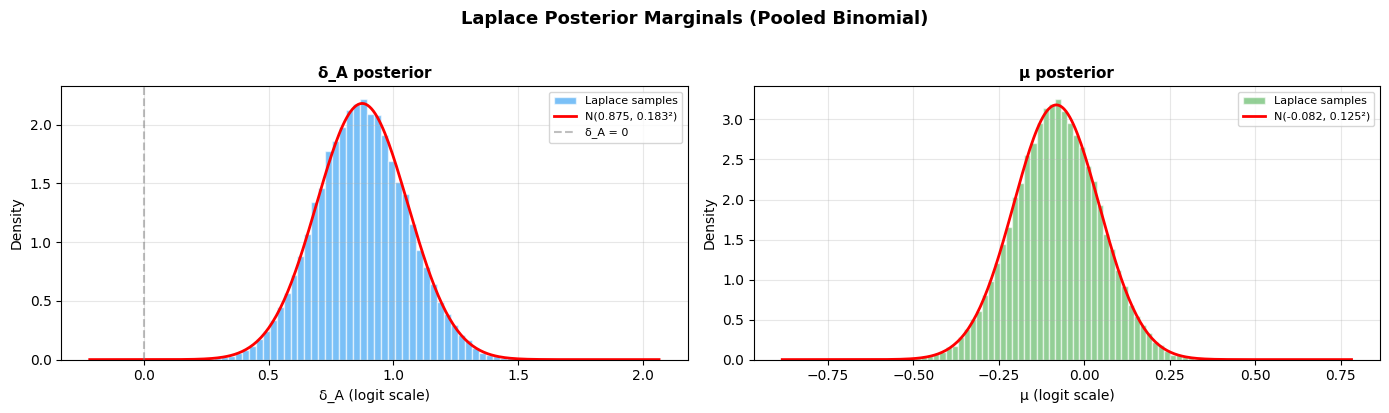

,mean,sd,hdi_3%,hdi_97%,MAP
delta_A,0.873654,0.182810,0.531065,1.220837,0.874840
mu,-0.081259,0.125559,-0.320000,0.155135,-0.081721


In [16]:
from scipy.stats import norm

laplace = model.laplace
mu_s = laplace["mu_samples"]
delta_s = laplace["delta_A_samples"]
mu_map, delta_map = laplace["map"]
cov = laplace["cov"]

print(f"MAP: μ={mu_map:.4f}, δ_A={delta_map:.4f}")
print(f"Posterior sd: μ={np.sqrt(cov[0, 0]):.4f}, δ_A={np.sqrt(cov[1, 1]):.4f}")
print(f"Correlation: {cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1]):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# δ_A
ax = axes[0]
ax.hist(delta_s, bins=60, density=True, alpha=0.6, color="#2196F3", edgecolor="white", label="Laplace samples")
x = np.linspace(delta_s.min() - 0.3, delta_s.max() + 0.3, 300)
sd_d = np.sqrt(cov[1, 1])
ax.plot(x, norm.pdf(x, delta_map, sd_d), "r-", lw=2, label=f"N({delta_map:.3f}, {sd_d:.3f}²)")
ax.axvline(0, color="gray", ls="--", alpha=0.5, label="δ_A = 0")
ax.set_xlabel("δ_A (logit scale)")
ax.set_ylabel("Density")
ax.set_title("δ_A posterior", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# μ
ax = axes[1]
ax.hist(mu_s, bins=60, density=True, alpha=0.6, color="#4CAF50", edgecolor="white", label="Laplace samples")
x_mu = np.linspace(mu_s.min() - 0.3, mu_s.max() + 0.3, 300)
sd_m = np.sqrt(cov[0, 0])
ax.plot(x_mu, norm.pdf(x_mu, mu_map, sd_m), "r-", lw=2, label=f"N({mu_map:.3f}, {sd_m:.3f}²)")
ax.set_xlabel("μ (logit scale)")
ax.set_ylabel("Density")
ax.set_title("μ posterior", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("Laplace Posterior Marginals (Pooled Binomial)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(IMG_DIR / "laplace_posterior_marginals.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

display(model.trace_summary)

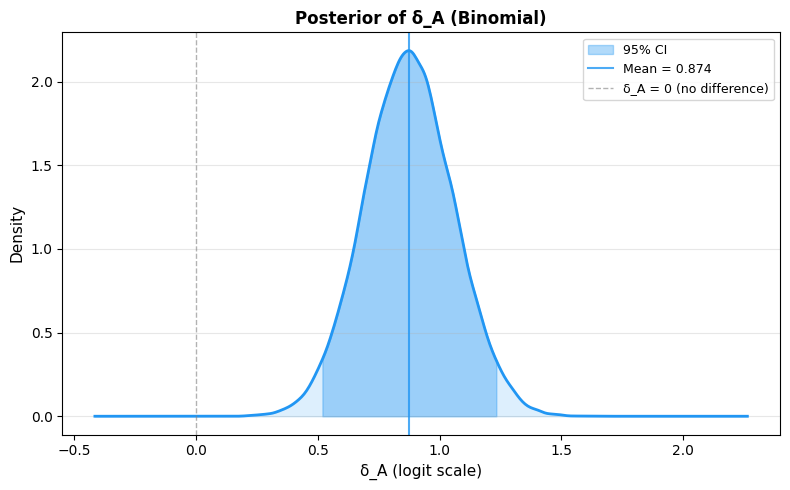

In [17]:
from scipy.stats import gaussian_kde

samples = model.delta_A_samples
ci_low, ci_high = np.quantile(samples, [0.025, 0.975])
mean_val = samples.mean()

kde = gaussian_kde(samples)
x_grid = np.linspace(samples.min() - 0.5, samples.max() + 0.5, 500)
density = kde(x_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_grid, density, color="#2196F3", linewidth=2)
ax.fill_between(x_grid, density, alpha=0.15, color="#2196F3")

mask = (x_grid >= ci_low) & (x_grid <= ci_high)
ax.fill_between(x_grid[mask], density[mask], alpha=0.35, color="#2196F3", label="95% CI")

ax.axvline(mean_val, color="#2196F3", linestyle="-", linewidth=1.5, alpha=0.8, label=f"Mean = {mean_val:.3f}")
ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="δ_A = 0 (no difference)")

ax.set_xlabel("δ_A (logit scale)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Posterior of δ_A (Binomial)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "posterior_delta_A_kde.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### Posterior Predictive Check (PPC) — Binomial Model

For binary data, PPC is straightforward:
1. For each posterior draw, compute $p_{A,i} = \sigma(\theta_i + \delta_A)$ and $p_{B,i} = \sigma(\theta_i)$
2. Draw $y^{\text{rep}}_{A,i} \sim \text{Bernoulli}(p_{A,i})$ and $y^{\text{rep}}_{B,i} \sim \text{Bernoulli}(p_{B,i})$
3. Compare replicated statistics (fraction of 1s, pairwise differences) to observed data

Since the likelihood is exactly Bernoulli, the PPC should calibrate well — the model cannot "misfit" in the same way the Beta model did with boundary-concentrated continuous scores.

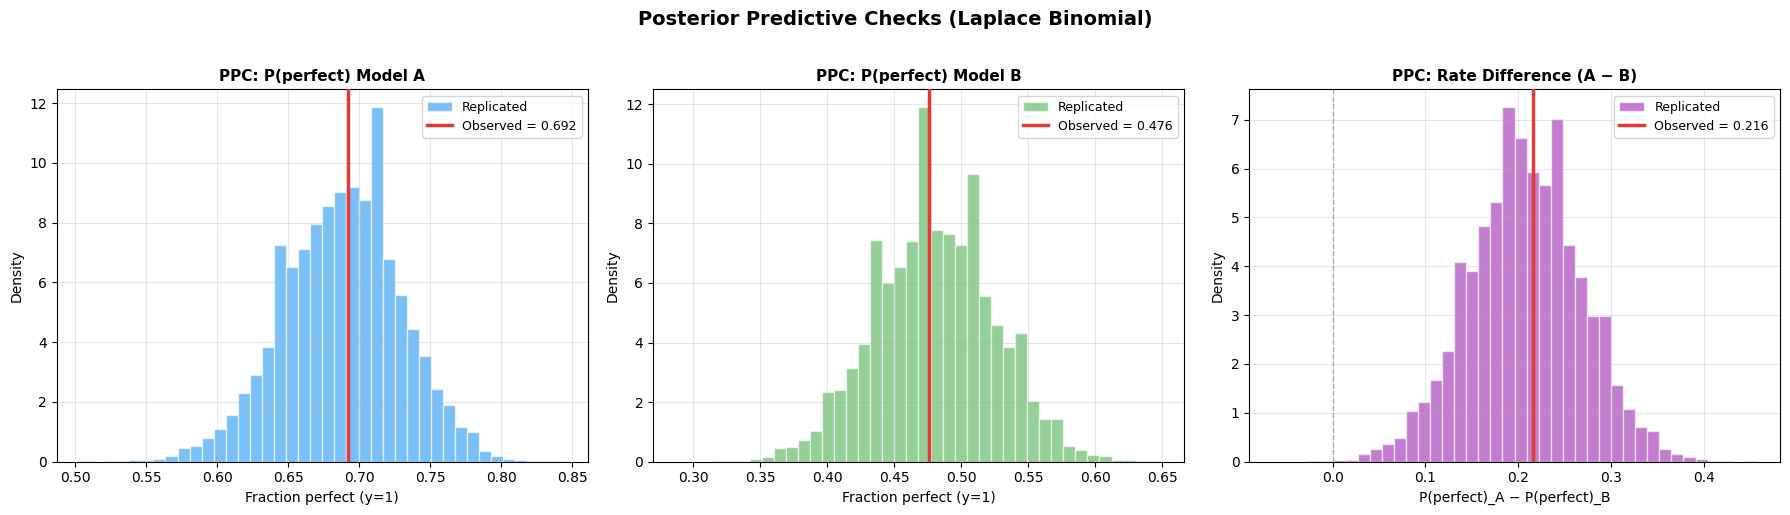

In [18]:
_show = plt.show
plt.show = lambda: None
model.plot_ppc(seed=42)
plt.savefig(IMG_DIR / "ppc_binomial_model.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show
plt.show()

In [19]:
ppc = model.ppc_pvalues(seed=42)

print("Posterior Predictive p-values (two-sided) — Binomial Model (Laplace)")
print("=" * 70)
print(f"{'Statistic':<20} {'Observed':>10} {'p-value':>10} {'Status':>10}")
print("-" * 70)
for stat_name, vals in ppc.items():
    print(f"{stat_name:<20} {vals.observed:>10.4f} {vals.p_value:>10.3f} {vals.status:>10}")
print("=" * 70)

Posterior Predictive p-values (two-sided) — Binomial Model (Laplace)
Statistic              Observed    p-value     Status
----------------------------------------------------------------------
mean(y_A)                0.6920      0.975         OK
mean(y_B)                0.4760      0.974         OK
mean(y_A-y_B)            0.2160      0.919         OK
std(y_A-y_B)             0.6398      0.118         OK
n_disagree             114.0000      0.145         OK


## Bayesian Hypothesis Test: $H_0: \Delta = 0$ vs $H_1: \Delta \neq 0$

### Interpretation scale (Jeffreys)

| $BF_{10}$ | Evidence against $H_0$ |
|-----------|----------------------|
| < 1 | Supports $H_0$ |
| 1 -- 3 | Anecdotal |
| 3 -- 10 | Moderate |
| 10 -- 30 | Strong |
| 30 -- 100 | Very strong |
| > 100 | Decisive |

In [20]:
d = model.decide()
bf = d.bayes_factor
pn = d.posterior_null
rp = d.rope

print("Hypothesis Test: H₀ (Δ = 0) vs H₁ (Δ ≠ 0) — Binomial Model")
print("=" * 70)
print(f"  Prior  density at δ=0: {bf.prior_density_at_0:.6f}")
print(f"  Post.  density at δ=0: {bf.posterior_density_at_0:.2e}")
print(f"  BF_01 (for H0):        {_format_bf(bf.BF_01)}")
print(f"  BF_10 (against H0):    {_format_bf(bf.BF_10)}")
print(f"  log₁₀(BF_10):          {np.log10(bf.BF_10):.1f}")
print(f"  → {bf.interpretation}")
print(f"  → BF Decision:         {bf.decision}")
print(f"  → P(H₀|D) = {pn.p_H0:.4f}  → {pn.decision}")
print(f"  → ROPE [{rp.rope_lower:.2f}, {rp.rope_upper:.2f}]: {rp.decision}  ({rp.pct_in_rope:.1%} in ROPE)")
print("=" * 70)

Hypothesis Test: H₀ (Δ = 0) vs H₁ (Δ ≠ 0) — Binomial Model
  Prior  density at δ=0: 0.398942
  Post.  density at δ=0: 2.35e-05
  BF_01 (for H0):        10^-4
  BF_10 (against H0):    10^4
  log₁₀(BF_10):          4.2
  → Decisive evidence against H0
  → BF Decision:         Reject H0
  → P(H₀|D) = 0.0001  → Reject H0
  → ROPE [-0.02, 0.02]: Reject H0 — A practically better  (0.0% in ROPE)


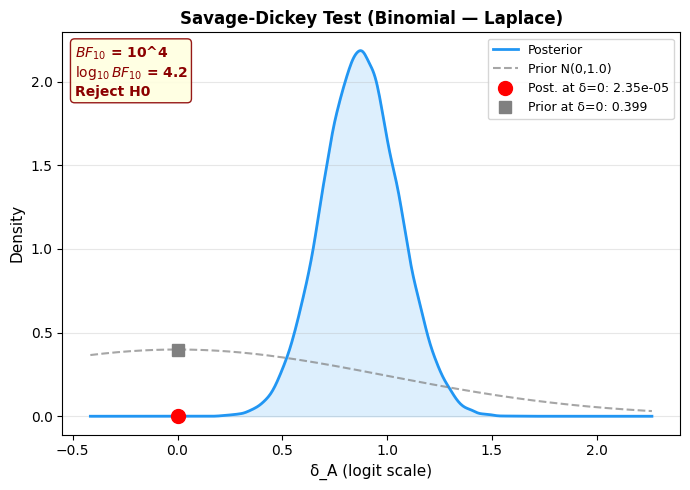

In [21]:
_show = plt.show
plt.show = lambda: None
model.plot_savage_dickey(title="Savage-Dickey Test (Binomial — Laplace)")
plt.savefig(IMG_DIR / "savage_dickey_bf_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show
plt.show()

### From Bayes Factor to Posterior Probability of $H_0$

$$
P(H_0 \mid D) = \frac{\pi_0 \cdot BF_{01}}{\pi_0 \cdot BF_{01} + (1 - \pi_0)}
$$

With the default agnostic prior $\pi_0 = 0.5$: $P(H_0 \mid D) = BF_{01}/(1 + BF_{01})$.

In [22]:
prior_H0 = 0.5

pn = d.posterior_null
print(f"Prior: P(H₀) = {prior_H0}, P(H₁) = {1 - prior_H0}")
print("=" * 60)
print(f"  P(H₀|data) = {pn.p_H0:.2e}")
print(f"  P(H₁|data) = {pn.p_H1:.6f}")
print(f"  Decision:    {pn.decision}")
print("=" * 60)

Prior: P(H₀) = 0.5, P(H₁) = 0.5
  P(H₀|data) = 5.89e-05
  P(H₁|data) = 0.999941
  Decision:    Reject H0


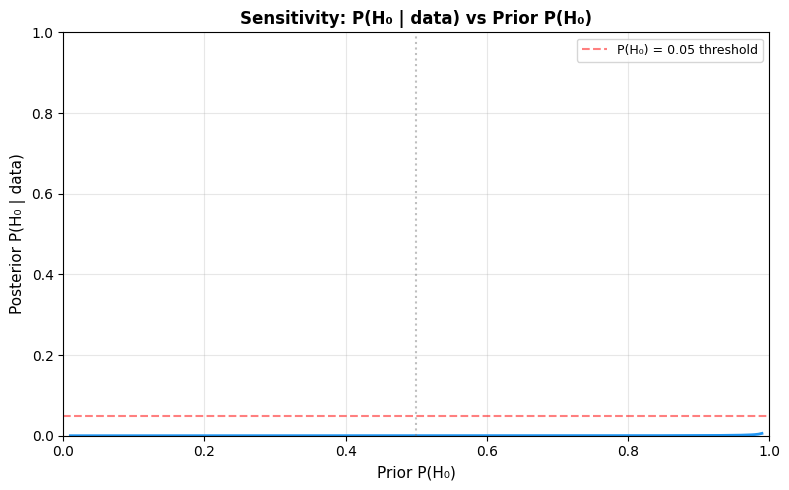

In [23]:
from scipy.stats import norm

prior_grid = np.linspace(0.01, 0.99, 200)
p_h0_grid = [PairedBayesPropTest.posterior_probability_H0(bf.BF_01, p).p_H0 for p in prior_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(prior_grid, p_h0_grid, linewidth=2, color="#2196F3")
ax.axhline(0.05, color="red", linestyle="--", alpha=0.5, label="P(H₀) = 0.05 threshold")
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Prior P(H₀)", fontsize=11)
ax.set_ylabel("Posterior P(H₀ | data)", fontsize=11)
ax.set_title("Sensitivity: P(H₀ | data) vs Prior P(H₀)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(IMG_DIR / "sensitivity_prior_h0_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### Sensitivity to the slab width $\sigma_s$

The Bayes Factor depends on the choice of slab width $\sigma_s$ (Jeffreys-Lindley effect). We assess robustness by sweeping $\sigma_s$ over a range of plausible values.

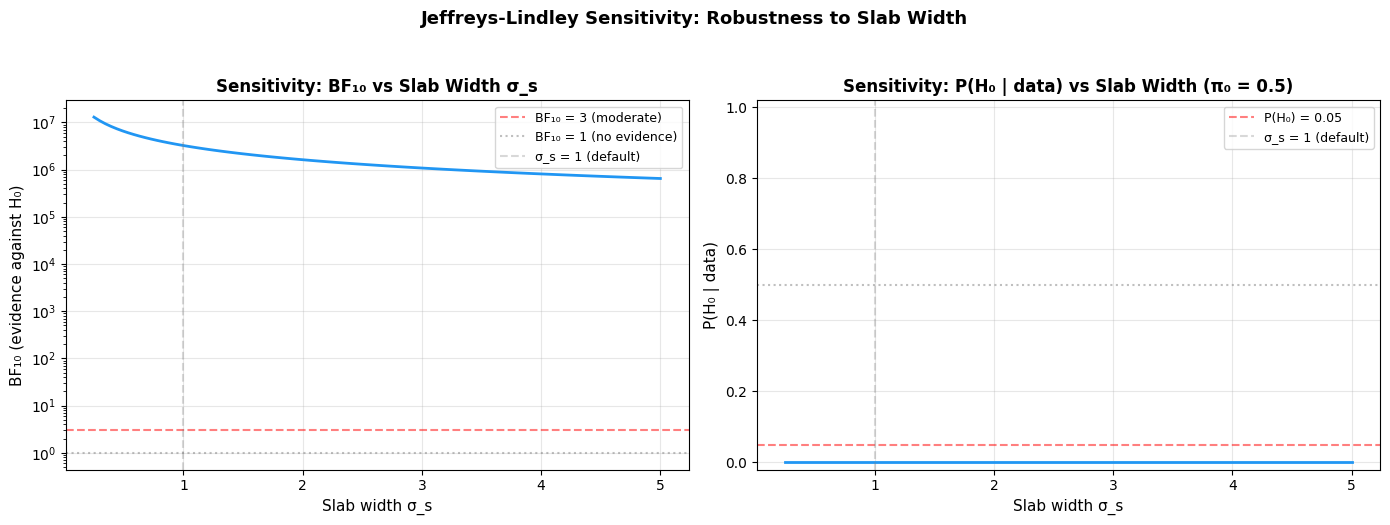

In [24]:
sigma_grid = np.linspace(0.25, 5.0, 100)

samples = model.delta_A_samples
kde = gaussian_kde(samples)
post_at_0 = float(kde(0.0)[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BF₁₀ vs slab width
ax = axes[0]
bf10_vals = [norm.pdf(0, 0, s) / post_at_0 for s in sigma_grid]
ax.plot(sigma_grid, bf10_vals, linewidth=2, color="#2196F3")
ax.axhline(3, color="red", linestyle="--", alpha=0.5, label="BF₁₀ = 3 (moderate)")
ax.axhline(1, color="gray", linestyle=":", alpha=0.5, label="BF₁₀ = 1 (no evidence)")
ax.axvline(1.0, color="gray", linestyle="--", alpha=0.3, label="σ_s = 1 (default)")
ax.set_xlabel("Slab width σ_s", fontsize=11)
ax.set_ylabel("BF₁₀ (evidence against H₀)", fontsize=11)
ax.set_title("Sensitivity: BF₁₀ vs Slab Width σ_s", fontsize=12, fontweight="bold")
ax.set_yscale("log")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# P(H₀) vs slab width
ax2 = axes[1]
p_h0_vals = []
for s in sigma_grid:
    prior_at_0 = norm.pdf(0, 0, s)
    bf01 = post_at_0 / prior_at_0
    p_h0 = bf01 / (1 + bf01)
    p_h0_vals.append(p_h0)

ax2.plot(sigma_grid, p_h0_vals, linewidth=2, color="#2196F3")
ax2.axhline(0.05, color="red", linestyle="--", alpha=0.5, label="P(H₀) = 0.05")
ax2.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax2.axvline(1.0, color="gray", linestyle="--", alpha=0.3, label="σ_s = 1 (default)")
ax2.set_xlabel("Slab width σ_s", fontsize=11)
ax2.set_ylabel("P(H₀ | data)", fontsize=11)
ax2.set_title("Sensitivity: P(H₀ | data) vs Slab Width (π₀ = 0.5)", fontsize=12, fontweight="bold")
ax2.set_ylim(-0.02, 1.02)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle("Jeffreys-Lindley Sensitivity: Robustness to Slab Width", fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
fig.savefig(IMG_DIR / "sensitivity_slab_width_binomial.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### Bayes Factor Design Analysis (BFDA) — Sample Size Planning (Paired Design)

In frequentist testing we compute the **power** — the probability of rejecting H₀ given a true effect.
The Bayesian analog is **Bayes Factor Design Analysis**: for a hypothesised true effect
$\Delta = \theta_A - \theta_B$, simulate many paired datasets at each sample size and estimate the
probability of obtaining *decisive* evidence (e.g. $BF_{10} > 3$).

In [25]:
from bayesprop.utils.utils import (
    bfda_power_curve,
    find_n_for_power,
    plot_bfda_power,
    plot_bfda_sensitivity,
)

# ── Use simulated rates as plug-in estimates for the true effect ──────
theta_A_hat = y_A.mean()
theta_B_hat = y_B.mean()

print("Assumed true rates (from simulated data):")
print(f"  θ_A = {theta_A_hat:.3f}")
print(f"  θ_B = {theta_B_hat:.3f}")
print(f"  True Δ = {theta_A_hat - theta_B_hat:.3f} (effect size)")
print()

# ── Compute BFDA power curve (paired design) ─────────────────────────
sample_sizes = [20, 30, 50, 75, 100, 150, 200, 300, 500]

power_curve_paired = bfda_power_curve(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    design="paired",
    decision_rule="bayes_factor",
    bf_threshold=3.0,
    n_sim=200,
    n_iter=1000,
    burn_in=300,
    n_chains=2,
    seed=42,
)

print(f"{'n (per group)':<15} {'P(BF₁₀ > 3)':>12}")
print("-" * 28)
for n, p in power_curve_paired.items():
    print(f"{n:<15} {p:>12.3f}")

n_80 = find_n_for_power(power_curve_paired, 0.80)
print(f"\n→ Estimated n for 80% power: ≈ {n_80:.0f}" if n_80 else "\n→ n for 80% power: > 500")

Assumed true rates (from simulated data):
  θ_A = 0.692
  θ_B = 0.476
  True Δ = 0.216 (effect size)

n (per group)    P(BF₁₀ > 3)
----------------------------
20                     0.045
30                     0.085
50                     0.125
75                     0.190
100                    0.285
150                    0.430
200                    0.690
300                    0.865
500                    0.990

→ Estimated n for 80% power: ≈ 263


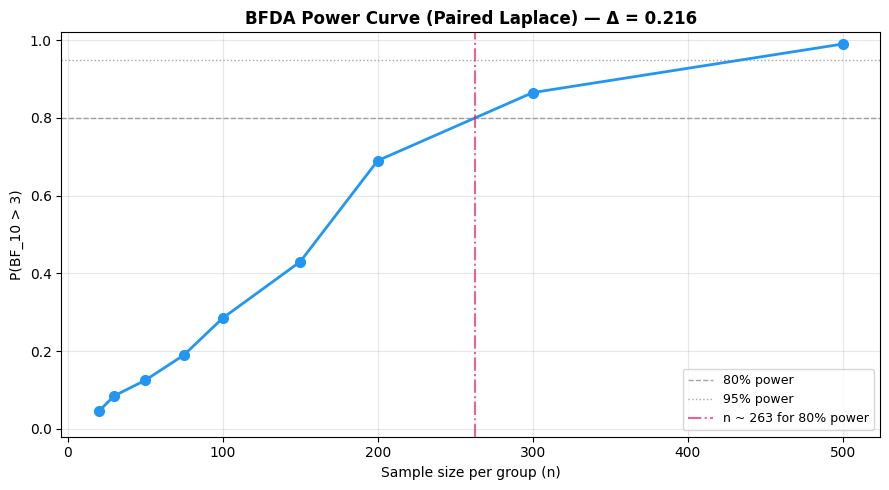

In [26]:
fig = plot_bfda_power(
    power_curve_paired,
    theta_A_hat,
    theta_B_hat,
    title=f"BFDA Power Curve (Paired Laplace) — Δ = {theta_A_hat - theta_B_hat:.3f}",
)
fig.savefig(IMG_DIR / "bfda_power_curve_paired_laplace.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

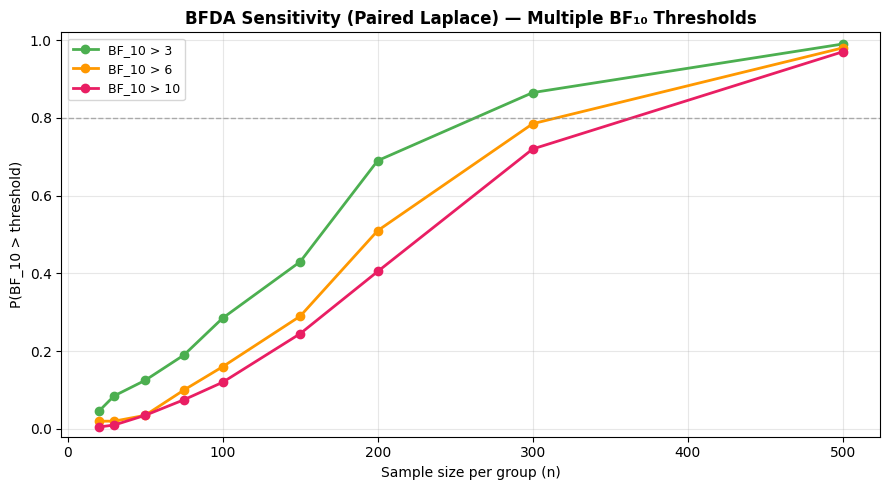

In [27]:
fig = plot_bfda_sensitivity(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    thresholds=[3.0, 6.0, 10.0],
    n_sim=200,
    seed=42,
    design="paired",
    title="BFDA Sensitivity (Paired Laplace) — Multiple BF₁₀ Thresholds",
)
fig.savefig(IMG_DIR / "bfda_sensitivity_thresholds_paired.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### BFDA via posterior probability of H₀ (Paired)

Since $P(H_0 \mid \text{data})$ is a monotonic transformation of $BF_{01}$:

$$
P(H_0 \mid \text{data}) = \frac{BF_{01} \cdot \pi_0}{BF_{01} \cdot \pi_0 + (1 - \pi_0)}
$$

we can equivalently define "decisive evidence" as $P(H_0) < \alpha$ for some threshold $\alpha$.
For equal prior odds ($\pi_0 = 0.5$), the correspondence is:

| $BF_{10}$ threshold | $P(H_0)$ threshold |
|:---:|:---:|
| 3 | 0.250 |
| 6 | 0.143 |
| 10 | 0.091 |
| 20 | 0.048 |

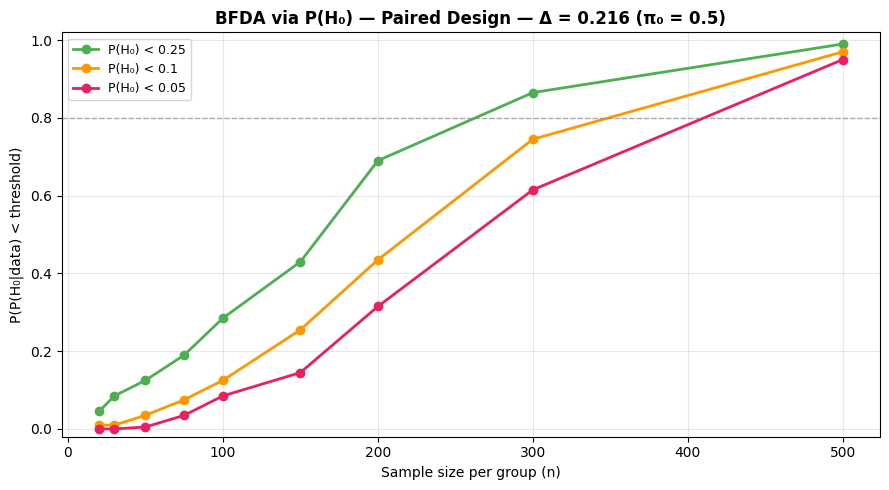


P(H₀) thresh    ≡ BF₁₀ >      n for 80% power
---------------------------------------------
0.25            3.0                     ≈ 263
0.10            9.0                     ≈ 349
0.05            19.0                    ≈ 410


In [28]:
# ── Power curves for different P(H₀) thresholds (paired design) ──────
fig, ax = plt.subplots(figsize=(9, 5))

ph0_thresholds = [0.25, 0.10, 0.05]
colors_ph0 = ["#4CAF50", "#FF9800", "#E91E63"]

for thresh, col in zip(ph0_thresholds, colors_ph0, strict=False):
    curve = bfda_power_curve(
        theta_A_true=theta_A_hat,
        theta_B_true=theta_B_hat,
        sample_sizes=sample_sizes,
        design="paired",
        decision_rule="posterior_null",
        ph0_threshold=thresh,
        n_sim=200,
        seed=42,
    )
    ax.plot(
        list(curve.keys()), list(curve.values()), "o-", color=col, linewidth=2, markersize=6, label=f"P(H₀) < {thresh}"
    )

ax.axhline(0.80, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Sample size per group (n)")
ax.set_ylabel("P(P(H₀|data) < threshold)")
ax.set_title(
    f"BFDA via P(H₀) — Paired Design — Δ = {theta_A_hat - theta_B_hat:.3f} (π₀ = 0.5)",
    fontsize=12,
    fontweight="bold",
)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "bfda_ph0_threshold_curves.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# ── Print equivalence table ───────────────────────────────────────────
print(f"\n{'P(H₀) thresh':<15} {'≡ BF₁₀ >':<12} {'n for 80% power':>16}")
print("-" * 45)
for thresh in ph0_thresholds:
    bf10_equiv = (1 - thresh) / thresh
    curve = bfda_power_curve(
        theta_A_true=theta_A_hat,
        theta_B_true=theta_B_hat,
        sample_sizes=sample_sizes,
        design="paired",
        decision_rule="posterior_null",
        ph0_threshold=thresh,
        n_sim=200,
        seed=42,
    )
    n_80 = find_n_for_power(curve, 0.80)
    n_str = f"≈ {n_80:.0f}" if n_80 is not None else "> 500"
    print(f"{thresh:<15.2f} {bf10_equiv:<12.1f} {n_str:>16}")